<a href="https://colab.research.google.com/github/enis-gosic/product-title-classification-ML-project/blob/main/notebook/product_title_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Product Category Classification using Machine Learning  
## Automatic Classification of Products Based on Their Titles

This project simulates a real-world problem in e-commerce: thousands of new products need to be correctly categorized every day.  
Manual categorization is slow, expensive, and prone to errors — which is why we develop an ML model that automatically suggests the appropriate category based on the *Product Title*.

**Dataset:** 30,000+ products (products.csv)

**Goal:** Train a model that accurately predicts a product's category based on its title.

**Author:** *Enis Gosic*

## 🎯 Project Objective

The goal is to build a machine learning model that classifies products into categories using only their name (*Product Title*).

This project simulates real work in an e-commerce data team and covers all key phases of an ML pipeline:
- data analysis  
- cleaning and preprocessing  
- feature engineering  
- text vectorization  
- comparison of multiple ML models  
- performance evaluation  
- saving the final model  
- creating scripts for training and prediction  
- documentation and GitHub project organization


## 📥 Loading and Inspecting the Dataset

Before diving into analysis, we first need to load the dataset and take a look at its structure.

In this step, we will:
- Load the CSV file from GitHub
- Check how many rows and columns we have
- Display the first few rows
- Review data types and basic metadata for each column

This helps us understand the structure of the dataset before performing text preprocessing and training ML models.


In [103]:
# Import libraries
import pandas as pd


# Load dataset from the GitHub
url = "https://raw.githubusercontent.com/enis-gosic/product-title-classification-ML-project/main/data/products.csv"

df = pd.read_csv(url)

# Print shape (number of rows and columns)
print("📊 Dataset shape (rows, columns):", df.shape)

# Show first 5 rows
print("\n 📌 First five rows:")
display(df.head())

# Show dataset info
print("\nℹ Dataset info:")
df.info()


📊 Dataset shape (rows, columns): (35311, 8)

 📌 First five rows:


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023



ℹ Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  object 
 2   Merchant ID      35311 non-null  int64  
 3    Category Label  35267 non-null  object 
 4   _Product Code    35216 non-null  object 
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7    Listing Date    35252 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.2+ MB


## 🛠 Cleaning Column Names and Handling Missing Values

Our dataset has messy column names with extra spaces, underscores, and inconsistent capitalization.

Missing data can cause problems during model training or analysis.  

Before we proceed with analysis, we need to:

- Standardize column names (lowercase, remove spaces, replace spaces with underscores)  
- Count the number of missing (NaN) values per column
- Visualize missing values using a heatmap:
  - This will help us identify any columns that require cleaning or imputation.
- Decide how to handle missing values based on the importance of each column:

Key points:
- `product_title` and `category_label` are essential for model training → drop rows with missing values in these columns  
- Other columns (`merchant_rating`, `listing_date`, etc.) can be left as is or filled later if needed


In [104]:
# Cleaning column names
df.columns = df.columns.str.strip()       # remove leading/trailing spaces
df.columns = df.columns.str.lstrip('_')   # remove _ from the beginning
df.columns = df.columns.str.lower()       # lowercase all letters
df.columns = df.columns.str.replace(' ', '_')  # replace spaces with underscores

# Check cleaned column names
print("Cleaned column names:")
print(df.columns)


Cleaned column names:
Index(['product_id', 'product_title', 'merchant_id', 'category_label',
       'product_code', 'number_of_views', 'merchant_rating', 'listing_date'],
      dtype='object')



Missing values per column:
product_id           0
product_title      172
merchant_id          0
category_label      44
product_code        95
number_of_views     14
merchant_rating    170
listing_date        59
dtype: int64


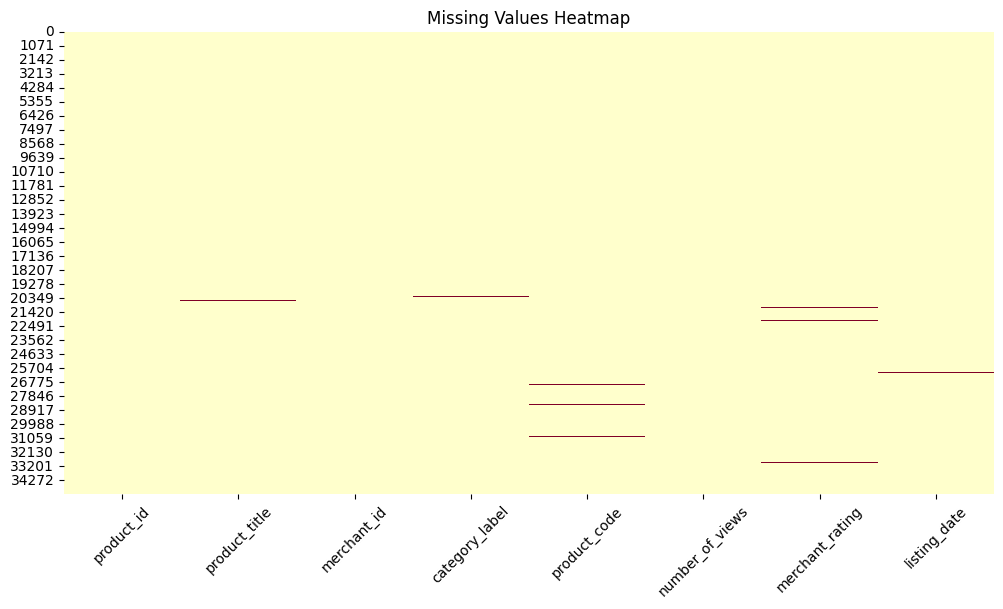

In [105]:
# Check missing values per column
print("\nMissing values per column:")
print(df.isna().sum())

# Visualize missing data with seaborn heatmap
import seaborn as sns
import matplotlib.pyplot as plt


# Heatmap of missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(), cbar=False, cmap="YlOrRd")
plt.title("Missing Values Heatmap")
plt.xticks(rotation=45)
plt.show()

In [106]:
# Drop rows with missing essential values
essential_cols = ['product_title', 'category_label']
df = df.dropna(subset=essential_cols)

# Confirm dataset shape and missing values
print("Dataset shape after removing missing essential values:", df.shape)
print("\nMissing values per column after cleaning:")
print(df.isna().sum())

Dataset shape after removing missing essential values: (35096, 8)

Missing values per column after cleaning:
product_id           0
product_title        0
merchant_id          0
category_label       0
product_code        94
number_of_views     14
merchant_rating    170
listing_date        58
dtype: int64


## 📊 Product Category Distribution

In this step, we analyze how many products belong to each category.  
This helps us to:
- Understand dataset balance  
- Detect if any category dominates the data  
- Prepare the dataset for later modeling and EDA steps  

Category distribution (BEFORE cleaning):
category_label
Fridge Freezers     5470
Washing Machines    4015
Mobile Phones       4002
CPUs                3747
TVs                 3541
Fridges             3436
Dishwashers         3405
Digital Cameras     2689
Microwaves          2328
Freezers            2201
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64

Category distribution (AFTER cleaning):
category_label
Fridge Freezers     5470
Mobile Phones       4057
Washing Machines    4015
CPUs                3831
Fridges             3559
TVs                 3541
Dishwashers         3405
Digital Cameras     2689
Microwaves          2328
Freezers            2201
Name: count, dtype: int64


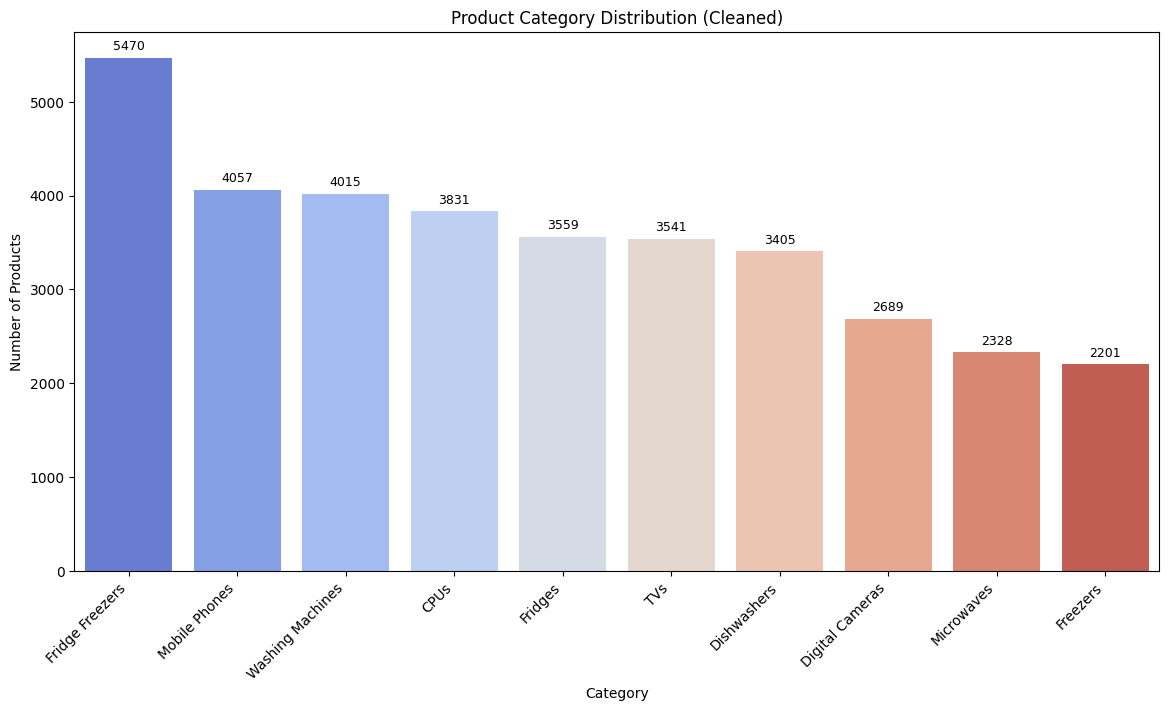

In [107]:
# ORIGINAL VALUES (before cleaning)
original_counts  = df['category_label'].value_counts().sort_values(ascending=False)

# Print values
print("Category distribution (BEFORE cleaning):")
print(original_counts )

# Map small variations to standard category names
category_map = {
    'Mobile Phone': 'Mobile Phones',
    'fridge': 'Fridges',
    'CPU': 'CPUs'
}

df['category_label'] = df['category_label'].replace(category_map)

# NEW VALUES (after cleaning)
cleaned_counts = df['category_label'].value_counts().sort_values(ascending=False)

# Checking new values
print("\nCategory distribution (AFTER cleaning):")
print(cleaned_counts)

# Plot category distribution
plt.figure(figsize=(14,7))
sns.barplot(
    x=cleaned_counts.index,
    y=cleaned_counts.values,
    hue=cleaned_counts.index,
    palette="coolwarm",
    legend=False
)

plt.title("Product Category Distribution (Cleaned)")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for i, count in enumerate(cleaned_counts.values):
    plt.text(i, count + max(cleaned_counts.values)*0.01, str(count),
             ha='center', va='bottom', fontsize=9)

plt.show()


### 🔧 Category Cleaning & Standardization  
During the inspection, we noticed several inconsistencies in category naming, such as:
- `Mobile Phone` instead of `Mobile Phones`
- `fridge` (lowercase) instead of `Fridges`
- `CPU` instead of `CPUs`

These variations represent the same product categories, which can negatively impact analysis and modeling.

To fix this, we created a **category mapping** to standardize the names:
- **Mobile Phone → Mobile Phones**  
- **fridge → Fridges**  
- **CPU → CPUs**

### 📑 Before Cleaning  
First, we displayed the original category distribution to identify inconsistent labels.

### 🧹 After Cleaning  
After applying the mapping, we generated a new distribution showing the corrected and unified categories.

### 📈 Visualization  
Finally, we visualized the cleaned category distribution using a bar plot, ensuring the plot reflects the updated category names.

## ✂️ Removing Irrelevant Columns for Model Training

In this step, we prepare the dataset for modeling by keeping only the relevant columns and removing unnecessary ones.  

**Columns we will keep:**
- `product_title` – the text feature that describes each product. This will be used to train the model to predict categories.
- `category_label` – the target variable that contains the product category.

**Columns we will remove:**
- `product_id` – unique identifier, not useful for prediction.
- `merchant_id` – identifier of the seller, irrelevant for product classification.
- `product_code` – internal codes, do not contribute to model training.
- `number_of_views` – could be used later, but for now not required.
- `merchant_rating` – similar, not needed at this stage.
- `listing_date` – date of product listing, will not be used for the initial model.

By keeping only the essential columns, we simplify the dataset and avoid feeding irrelevant information to the model.


In [108]:
# Drop columns that are not needed for model training
columns_to_drop = ['product_id', 'merchant_id', 'product_code', 'number_of_views', 'merchant_rating', 'listing_date']
df_model = df.drop(columns=columns_to_drop)

# Check remaining columns
print("Columns for modeling:")
print(df_model.columns)


Columns for modeling:
Index(['product_title', 'category_label'], dtype='object')


## 🛠 Feature Engineering on `product_title`

In addition to the raw product titles, we can create additional features to help the model learn patterns for classification:

1. **Title length (number of characters)** – Longer titles may contain more information.
2. **Word count** – Number of words in the product title.
3. **Presence of numbers** – Many product titles include numbers (e.g., storage capacity, model number).
4. **Presence of uppercase words** – Capitalized words may indicate brand names or important specifications.
5. **Maximum word length** – Helps identify long model codes or specifications.
6. **Special characters count** – Symbols like `-`, `/`, or `+` may carry meaningful information.

These engineered features can improve the predictive power of the model. We will add them as new columns in our dataset.


In [113]:
# Feature Engineering on 'product_title'

# 1️⃣ Title length (number of characters)
df_model['title_char_count'] = df_model['product_title'].astype(str).apply(len)

# 2️⃣ Word count
df_model['title_word_count'] = df_model['product_title'].astype(str).apply(lambda x: len(x.split()))

# 3️⃣ Presence of numbers
df_model['title_has_numbers'] = df_model['product_title'].str.contains(r'\d').astype(int)

# 4️⃣ Presence of uppercase words (excluding the first letter)
df_model['title_has_uppercase'] = df_model['product_title'].apply(lambda x: any(word.isupper() for word in x.split())).astype(int)

# 5️⃣ Maximum word length
df_model['title_max_word_length'] = df_model['product_title'].astype(str).apply(lambda x: max([len(word) for word in x.split()]) if x else 0)

# 6️⃣ Count of special characters
df_model['title_special_char_count'] = df_model['product_title'].astype(str).apply(lambda x: sum(not c.isalnum() and not c.isspace() for c in x))

# Preview the new dataset
df_model.head()


,product_title,category_label,title_char_count,title_word_count,title_has_numbers,title_has_uppercase,title_max_word_length,title_special_char_count
0,apple iphone 8 plus 64gb silver,Mobile Phones,31,6,1,0,6,0
1,apple iphone 8 plus 64 gb spacegrau,Mobile Phones,35,7,1,0,9,0
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,Mobile Phones,70,13,1,0,10,2
3,apple iphone 8 plus 64gb space grey,Mobile Phones,35,7,1,0,6,0
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,Mobile Phones,54,11,1,0,8,1
